# 02 — Exploratory Data Analysis: Austin Animal Shelter (Dogs & Cats)

**Goal:** understand what predicts **long stay** (`is_long_stay` — length of stay **> 30 days**, Austin Animal Center's official long-stay definition) for shelter animals, as preparation for a later modeling step. The operational motive: surface animals likely to occupy shelter space long-term so staff can intervene early. This notebook is **EDA only** — no cleaning, no feature engineering for a model, no training.

**Why dogs and cats are analyzed *separately, side by side* in every section (never pooled):**
1. Dog and Cat use different resources.
2. **Breed distributions don't overlap** — cats are dominated by *Domestic Shorthair*; dogs spread across *Pit Bull, Labrador, Chihuahua, German Shepherd, ...*

The dataset is already cleaned and pre-merged (one row per outcome event, each outcome joined to its intake record).

## 1. Setup & Load

### 1.1 Imports, data path & load
Load the cleaned, pre-merged dataset (already filtered to dogs & cats). `DATA_PATH` is the single knob to edit. The CSV already carries the calendar columns (`intake_year`, `intake_month`) that the temporal section (§5) reads directly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Consistent species colors used everywhere in this notebook
DOG_COLOR = 'steelblue'
CAT_COLOR = 'darkorange'

# ====== EDIT THIS IF YOUR DATA LIVES ELSEWHERE ======
DATA_PATH = '../data/processed/df_full_merged.csv'   # cleaned, pre-merged, already dog/cat only
# ====================================================
df = pd.read_csv(DATA_PATH)
print('Loaded:', df.shape)

df['animal_type'].value_counts(dropna=False)

Loaded: (162465, 26)


animal_type
Dog    93728
Cat    68737
Name: count, dtype: int64

In [2]:
# Guard: ensure the long-stay target exists (CSV may predate the is_long_stay column).
LONG_STAY_THRESHOLD = 30   # AAC official long-stay: length of stay strictly over 30 days
if 'is_long_stay' not in df.columns:
    df['is_long_stay'] = (df['length_of_stay_days'] > LONG_STAY_THRESHOLD).astype(int)
    print(f'WARNING: is_long_stay missing from CSV — recomputed in place '
          f'(length_of_stay_days > {LONG_STAY_THRESHOLD}).')
else:
    print('is_long_stay present in CSV — using stored column.')
print('is_long_stay nulls:', int(df['is_long_stay'].isna().sum()))

is_long_stay present in CSV — using stored column.
is_long_stay nulls: 0


### 1.2 Target & leakage columns


In [3]:
# For reference only — never feed these to a model.
# Target switched to is_long_stay, so the former target is_adopted and the outcome-derived
# outcome_category are now leakage sources too. length_of_stay_days stays here: it is the PARENT
# of the target (is_long_stay = length_of_stay_days > 30), perfectly correlated and unknown at
# intake -> never a feature, EDA-description only (§2.7).
LEAKAGE_COLS = [
    'outcome_type', 'outcome_subtype', 'outcome_date',
    'length_of_stay_days', 'is_adopted', 'outcome_category'
]
TARGET = 'is_long_stay'
print('Leakage (excluded from features):', LEAKAGE_COLS)
print('Target:', TARGET)

Leakage (excluded from features): ['outcome_type', 'outcome_subtype', 'outcome_date', 'length_of_stay_days', 'is_adopted', 'outcome_category']
Target: is_long_stay


### 1.3 Derive display-only columns (`age_bucket`)
`age_bucket` bins `age_at_intake_days` into ordered buckets.

In [4]:
# --- age_bucket: bin age_at_intake_days (display-only) ---
AGE_BINS   = [0, 60, 180, 365, 730, 1825, 3650, 5475, np.inf]
AGE_LABELS = ['<2mo', '2-6mo', '6-12mo', '1-2yr', '2-5yr', '5-10yr', '10-15yr', '15yr+']
df['age_bucket'] = pd.cut(
    df['age_at_intake_days'], bins=AGE_BINS, labels=AGE_LABELS, right=False
)
df['age_bucket'] = df['age_bucket'].cat.set_categories(AGE_LABELS, ordered=True)

print('age_bucket counts:')
print(df['age_bucket'].value_counts().reindex(AGE_LABELS))

age_bucket counts:
age_bucket
<2mo       34665
2-6mo      28385
6-12mo     13536
1-2yr      24032
2-5yr      39560
5-10yr     15885
10-15yr     5536
15yr+        866
Name: count, dtype: int64


### 1.4 Split into `dogs` / `cats` + class balance
Two convenience frames used side-by-side throughout. Prints per-species **long-stay rate** and the `is_long_stay` balance.

In [5]:
dogs = df[df['animal_type'] == 'Dog'].copy()
cats = df[df['animal_type'] == 'Cat'].copy()

# A label map so 0/1 flags render with readable names in plots
LABEL_MAP = {'is_mix': {0: 'Purebred', 1: 'Mix'}}

print(f'Dogs: {len(dogs):,} rows | long-stay rate = {dogs[TARGET].mean():.3f}')
print(f'Cats: {len(cats):,} rows | long-stay rate = {cats[TARGET].mean():.3f}')
print()
print('is_long_stay balance (counts):')
print(pd.crosstab(df['animal_type'], df[TARGET]))

Dogs: 93,728 rows | long-stay rate = 0.157
Cats: 68,737 rows | long-stay rate = 0.253

is_long_stay balance (counts):
is_long_stay      0      1
animal_type               
Cat           51327  17410
Dog           79052  14676


## 2. Univariate Analysis
_Each feature shown for dogs and cats side by side; never pooled._

### 2.1 `age_at_intake_days` — distribution & skew
Histograms per species, plus `describe()` and skewness (right-skew flagged for a later log/bucket decision).

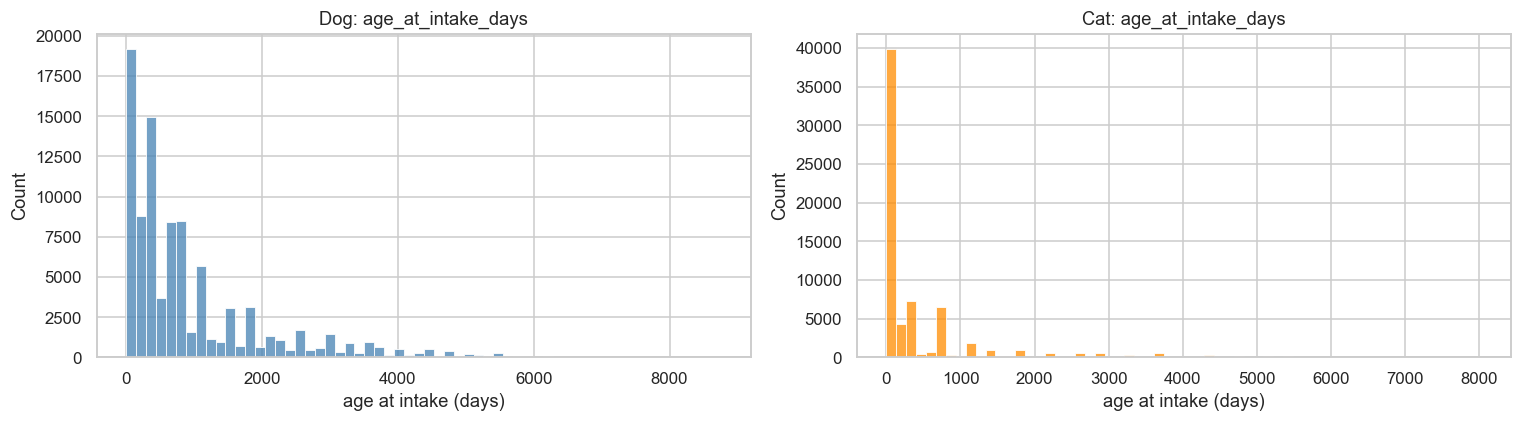

               Dog       Cat
count     93728.00  68737.00
mean        951.78    488.89
std        1105.55    939.39
min           0.00      0.00
25%         193.00     31.00
50%         612.00     83.00
75%        1117.00    427.00
max        8766.00   8036.00
skewness      1.93      3.21

Dog: skewness = 1.93  ->  STRONG right-skew -> consider log-transform or bucket
Cat: skewness = 3.21  ->  STRONG right-skew -> consider log-transform or bucket


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
for ax, (sp, frame, color) in zip(axes, [('Dog', dogs, DOG_COLOR), ('Cat', cats, CAT_COLOR)]):
    sns.histplot(frame['age_at_intake_days'].dropna(), bins=60, color=color, ax=ax)
    ax.set_title(f'{sp}: age_at_intake_days')
    ax.set_xlabel('age at intake (days)')
fig.tight_layout(); plt.show()

desc = pd.concat({'Dog': dogs['age_at_intake_days'].describe(),
                  'Cat': cats['age_at_intake_days'].describe()}, axis=1)
desc.loc['skewness'] = [dogs['age_at_intake_days'].skew(), cats['age_at_intake_days'].skew()]
print(desc.round(2))
print()
for sp, frame in [('Dog', dogs), ('Cat', cats)]:
    sk = frame['age_at_intake_days'].skew()
    flag = 'STRONG right-skew -> consider log-transform or bucket' if sk > 1 else 'mild skew'
    print(f'{sp}: skewness = {sk:.2f}  ->  {flag}')

### 2.2 `age_bucket` distribution

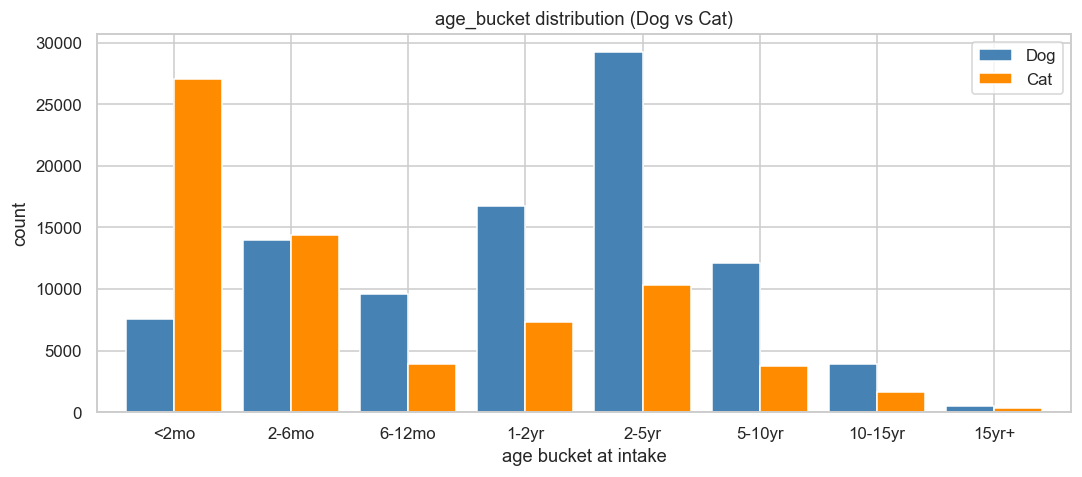

In [7]:
# bar chart of the age_bucket distribution (Dog vs Cat)
_ab = (df.groupby(['age_bucket', 'animal_type'], observed=True).size()
       .unstack(fill_value=0).reindex(AGE_LABELS))
_ab = _ab[[c for c in ['Dog', 'Cat'] if c in _ab.columns]]
ax = _ab.plot(kind='bar', figsize=(10, 4.5), width=0.82,
              color={'Dog': DOG_COLOR, 'Cat': CAT_COLOR})
ax.set_xlabel('age bucket at intake'); ax.set_ylabel('count')
ax.set_title('age_bucket distribution (Dog vs Cat)')
ax.legend(title='')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 2.3 Categorical features — `sex`, `intake_reason`, `intake_health_condition`, `is_mix`
Category proportions as pie charts (top-6 categories + `Other`), Dog vs Cat.

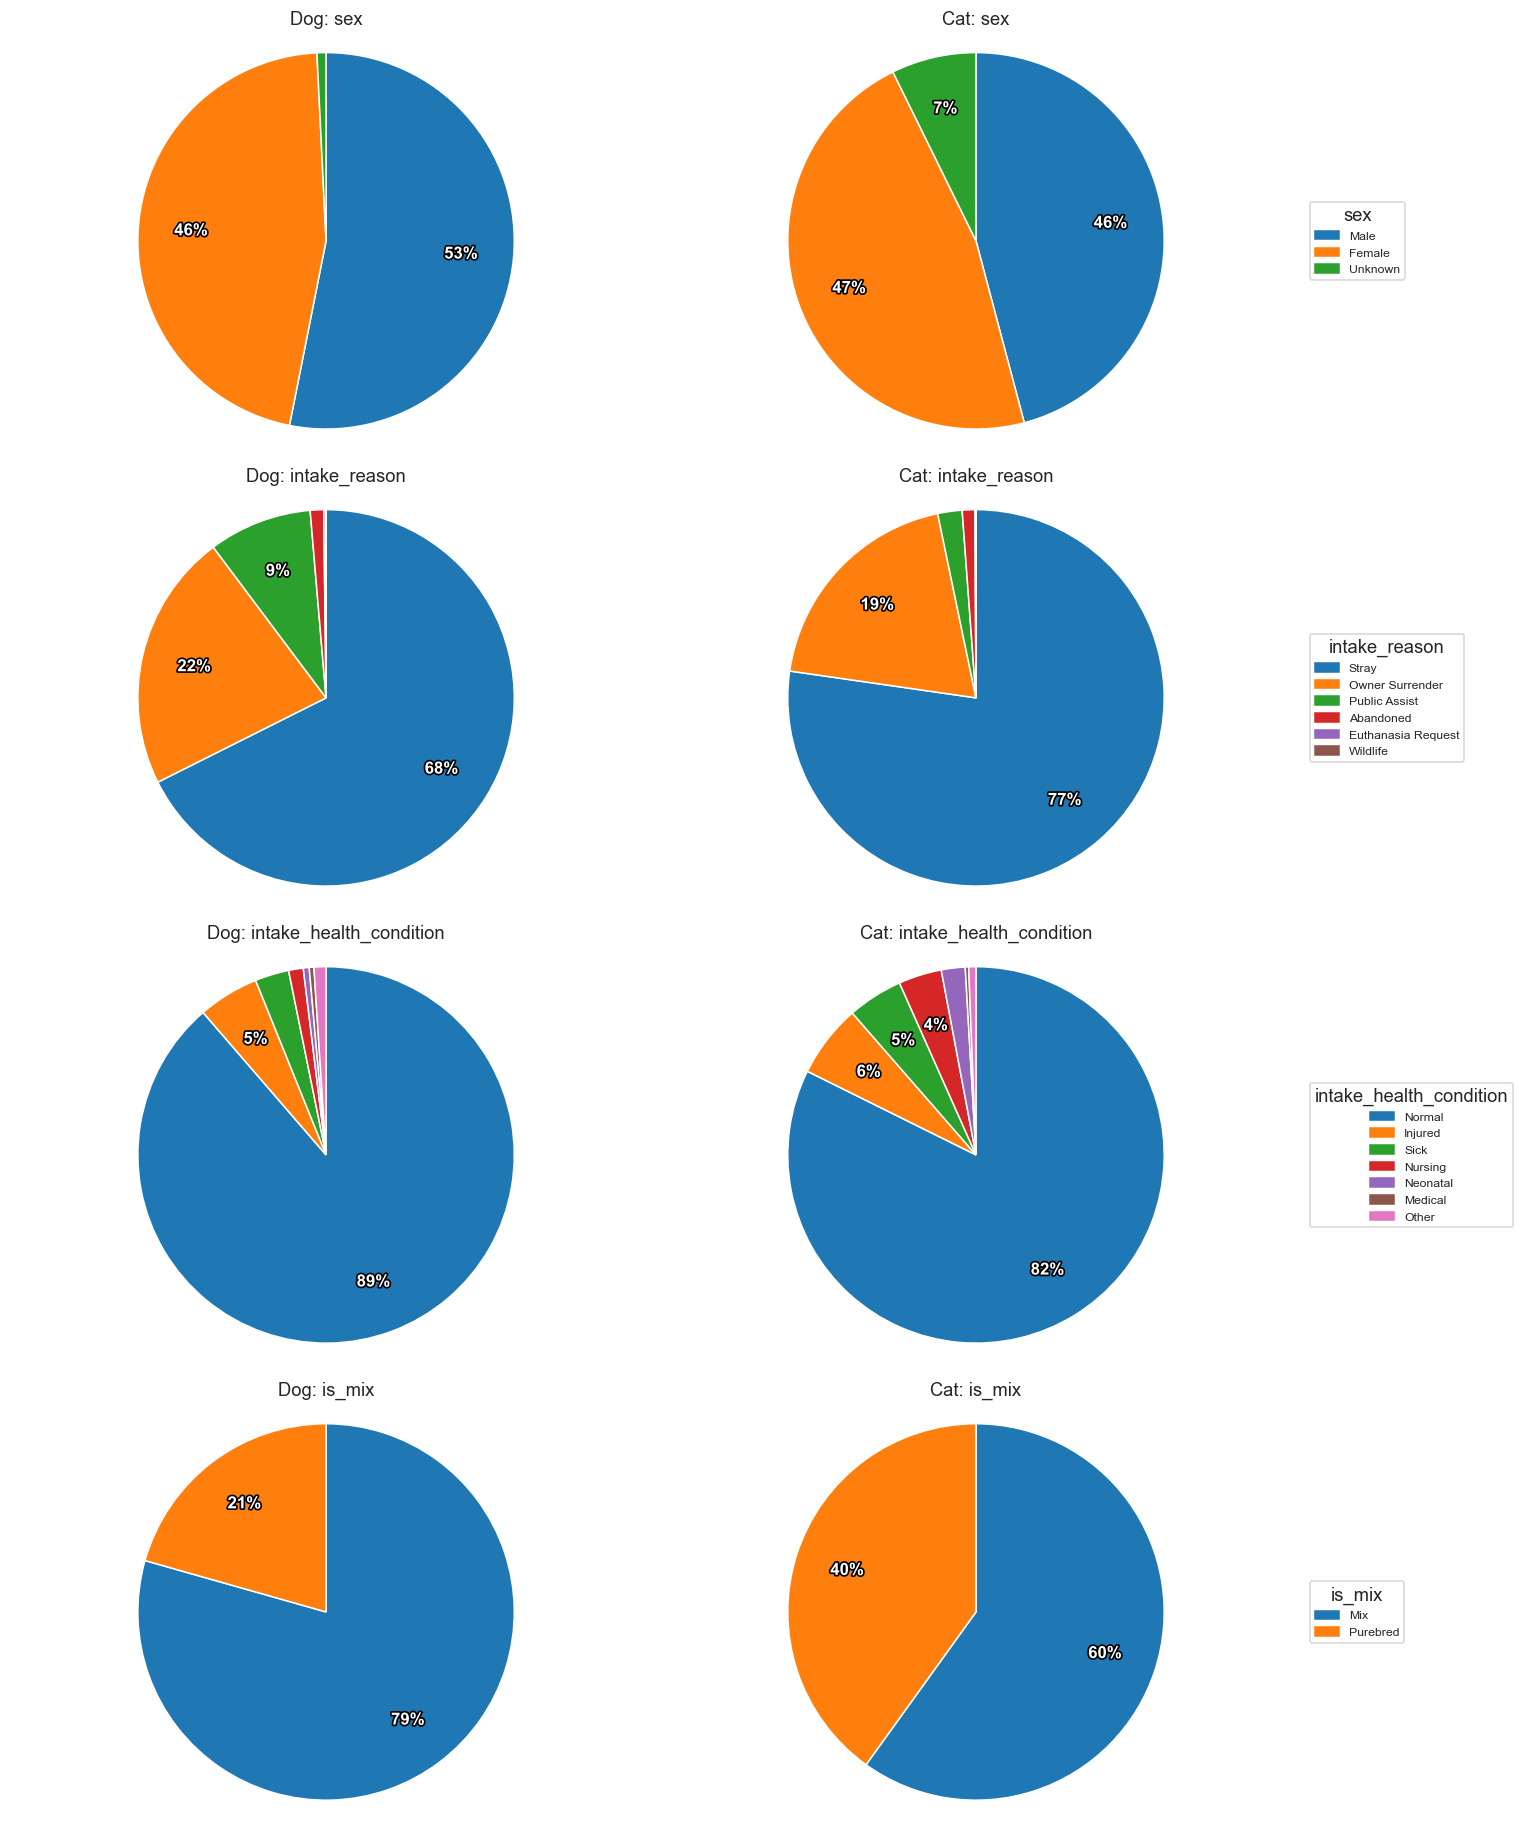

In [8]:
import matplotlib.patheffects as path_effects

cat_feats = ['sex', 'intake_reason', 'intake_health_condition', 'is_mix']
TOP_N = 6
fig, axes = plt.subplots(len(cat_feats), 2, figsize=(14, 4.2 * len(cat_feats)))

def _autopct(p):
    return f'{p:.0f}%' if p >= 3 else ''   # hide tiny slivers so labels don't overlap

for r, col in enumerate(cat_feats):
    # Determine category order ONCE across both species, keep top-N, lump rest into 'Other'.
    full_order = df[col].value_counts().index.tolist()
    keep = full_order[:TOP_N]
    has_other = len(full_order) > TOP_N
    cats_for_legend = keep + (['Other'] if has_other else [])
    cmap = plt.cm.tab20 if len(cats_for_legend) > 10 else plt.cm.tab10
    color_map = {cat: cmap(i % cmap.N) for i, cat in enumerate(cats_for_legend)}
    for c, (sp, frame) in enumerate([('Dog', dogs), ('Cat', cats)]):
        vc = frame[col].value_counts()
        sizes, slice_cats = [], []
        for cat in keep:
            sizes.append(vc.get(cat, 0)); slice_cats.append(cat)
        if has_other:
            sizes.append(vc.drop(labels=[k for k in keep if k in vc.index]).sum()); slice_cats.append('Other')
        colors = [color_map[cat] for cat in slice_cats]
        ax = axes[r, c]
        wedges, _, autotexts = ax.pie(
            sizes, colors=colors, autopct=_autopct, pctdistance=0.72,
            startangle=90, counterclock=False, normalize=True,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1})
        # Make the % labels clearly readable on ANY slice color: bold white + black outline.
        for t in autotexts:
            t.set_fontsize(11); t.set_fontweight('bold'); t.set_color('white')
            t.set_path_effects([path_effects.withStroke(linewidth=2.2, foreground='black')])
        ax.set_title(f'{sp}: {col}')
        ax.axis('equal')
    legend_labels = [str(LABEL_MAP.get(col, {}).get(cat, cat)) for cat in cats_for_legend]
    legend_handles = [plt.matplotlib.patches.Patch(color=color_map[cat]) for cat in cats_for_legend]
    axes[r, 1].legend(legend_handles, legend_labels, title=col,
                      loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
fig.tight_layout(); plt.show()

### 2.4 `primary_breed` — TOP 15 per species (separate plots; breeds do **not** overlap)

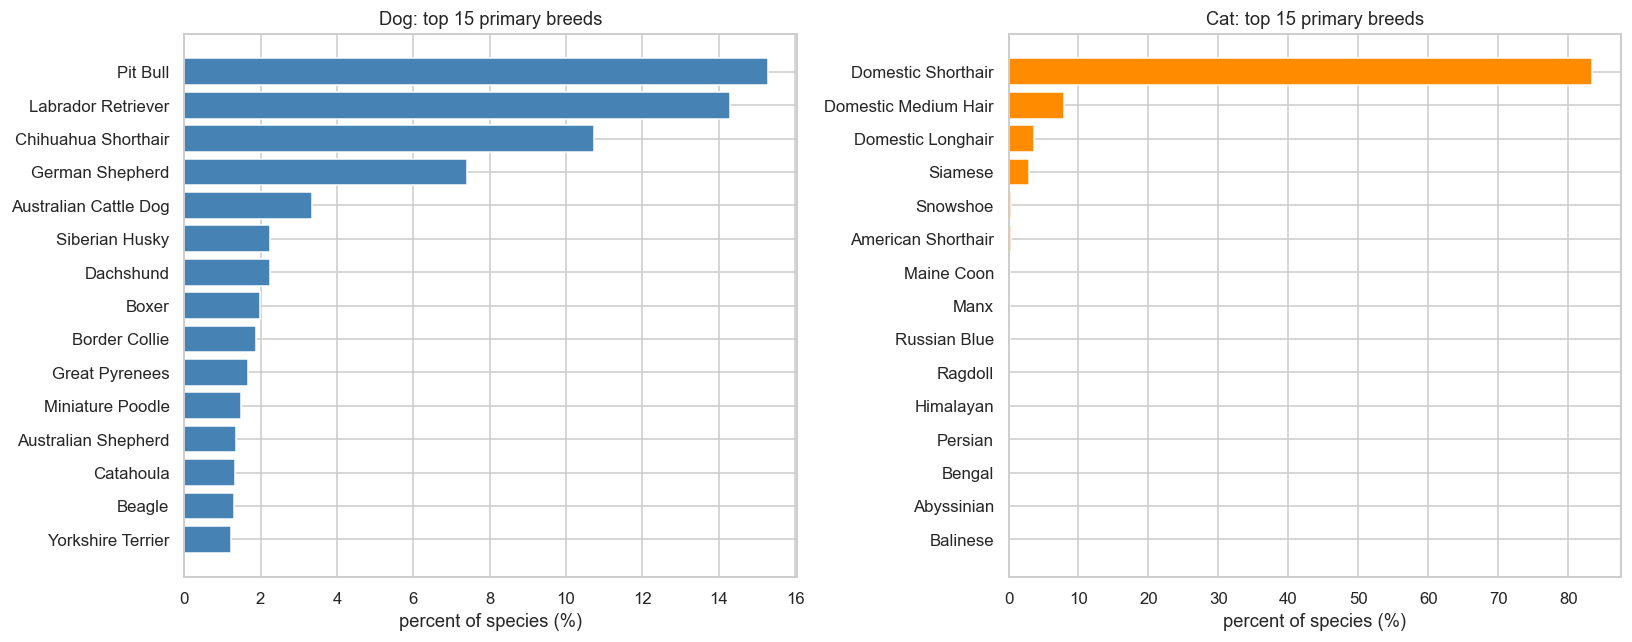

Dog: 211 unique breeds; 100 are rare (<50 rows).
Cat: 44 unique breeds; 33 are rare (<50 rows).


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (sp, frame, color) in zip(axes, [('Dog', dogs, DOG_COLOR), ('Cat', cats, CAT_COLOR)]):
    pct = frame['primary_breed'].value_counts(normalize=True).head(15) * 100
    ax.barh(pct.index[::-1], pct.values[::-1], color=color)
    ax.set_title(f'{sp}: top 15 primary breeds')
    ax.set_xlabel('percent of species (%)')
fig.tight_layout(); plt.show()

for sp, frame in [('Dog', dogs), ('Cat', cats)]:
    vc = frame['primary_breed'].value_counts()
    rare = int((vc < 50).sum())
    print(f'{sp}: {frame["primary_breed"].nunique()} unique breeds; '
          f'{rare} are rare (<50 rows).')

### 2.5 `primary_color` distribution — top 15 per species

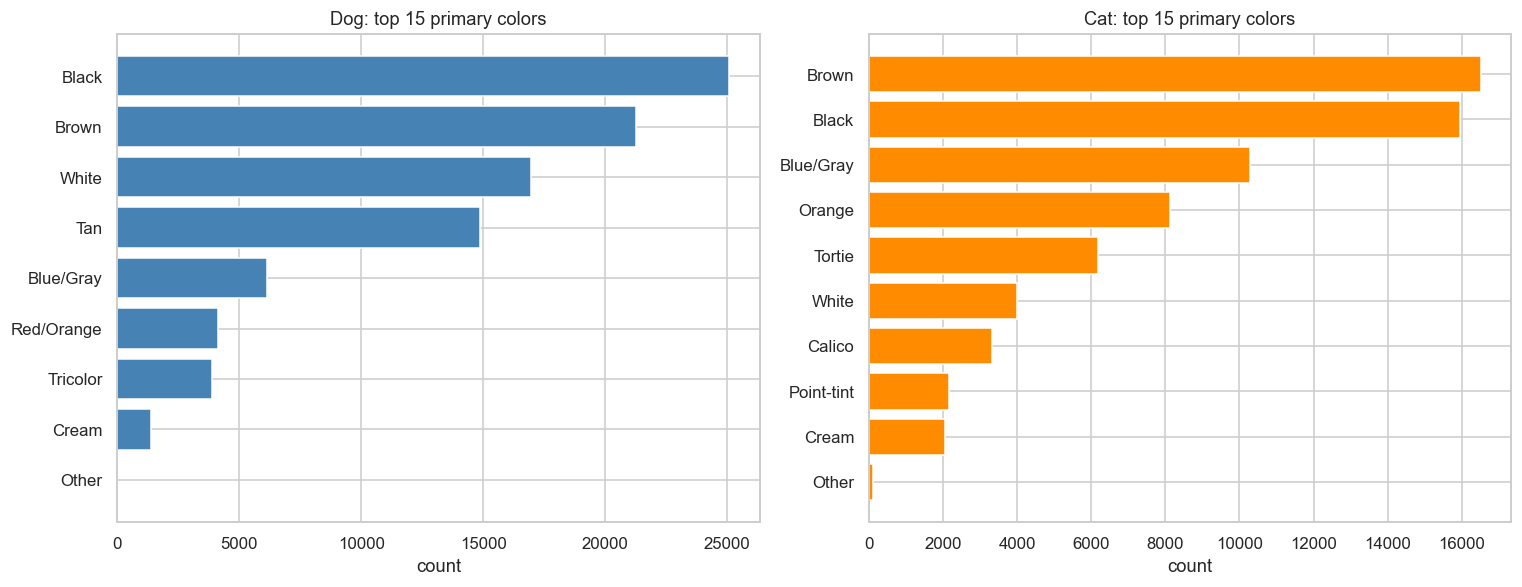

In [10]:
# top primary_color per species (horizontal bar, species side-by-side)
TOP_COLORS = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (sp, frame, color) in zip(axes, [('Dog', dogs, DOG_COLOR), ('Cat', cats, CAT_COLOR)]):
    vc = frame['primary_color'].value_counts().head(TOP_COLORS)
    ax.barh(vc.index[::-1], vc.values[::-1], color=color)
    ax.set_title(f'{sp}: top {TOP_COLORS} primary colors')
    ax.set_xlabel('count')
fig.tight_layout(); plt.show()

### 2.6 `outcome_subtype` distribution under each `outcome_type`
Heatmap of raw **counts** for each `outcome_subtype` × `outcome_type` pair (`(no subtype)` = subtype is NaN). A **log color scale** keeps small cells visible alongside the large ones; empty pairs are left blank. The x-axis (`outcome_type`) is placed on **top**. Both columns are **leakage** — shown only to understand how the target is built, never used as features.

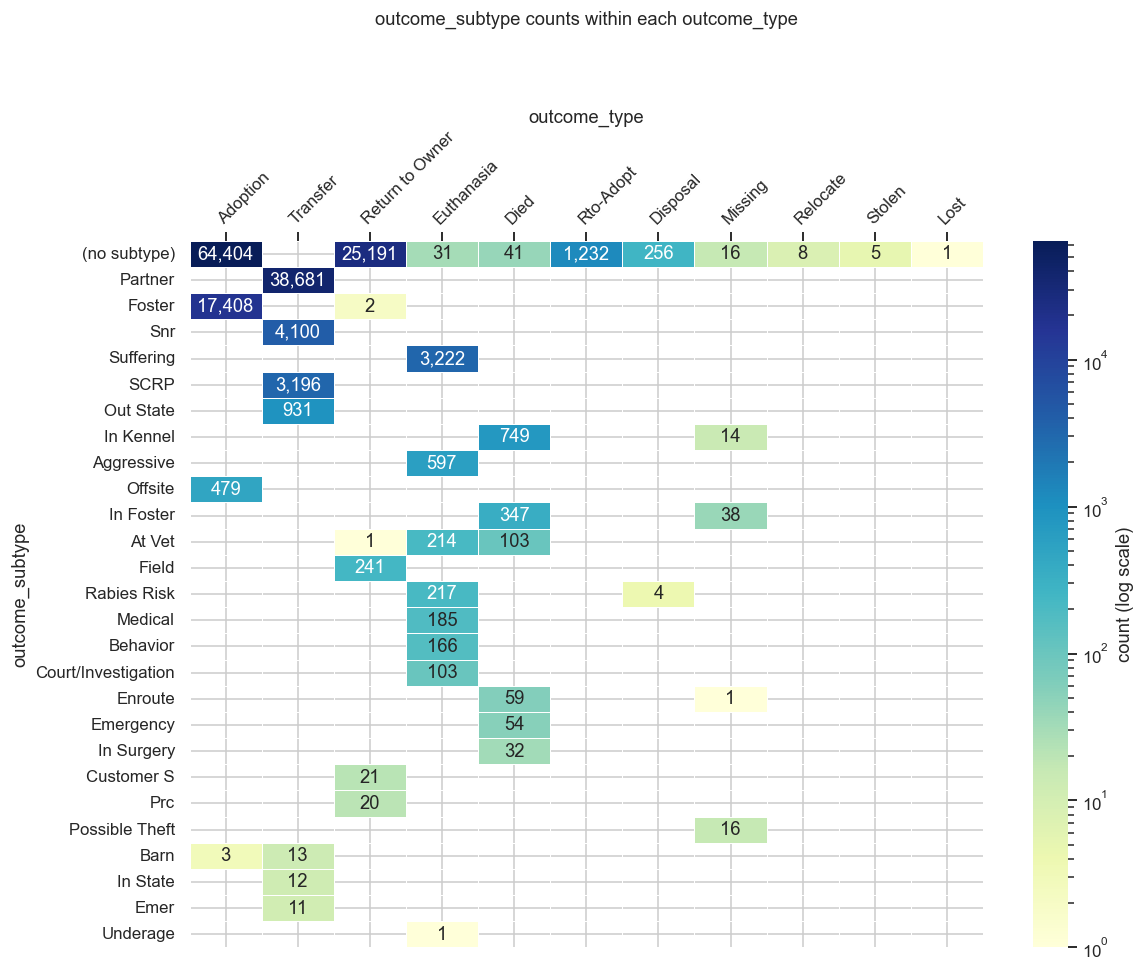

In [11]:
# outcome_subtype counts within each outcome_type (raw counts).
# Uses the full df (all dog/cat outcomes) so every outcome_type is shown.
# Both columns are LEAKAGE - displayed only to understand the target, never used as features.
from matplotlib.colors import LogNorm
ct = pd.crosstab(df['outcome_subtype'].fillna('(no subtype)'), df['outcome_type'])
ct = ct.loc[:, ct.sum(axis=0).sort_values(ascending=False).index]   # common outcome_types first
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]       # common subtypes first

annot = ct.map(lambda v: f'{v:,}' if v > 0 else '')                  # blank out empty cells
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(ct, annot=annot.values, fmt='', cmap='YlGnBu', mask=(ct == 0),
            norm=LogNorm(vmin=1, vmax=ct.values.max()),             # log scale so small cells stay visible
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'count (log scale)'}, ax=ax)
ax.set_title('outcome_subtype counts within each outcome_type', pad=55)
ax.set_xlabel('outcome_type'); ax.set_ylabel('outcome_subtype')
# put the x-axis label and ticks on the TOP of the graph
ax.xaxis.set_label_position('top')
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
plt.setp(ax.get_xticklabels(), rotation=45, ha='left', rotation_mode='anchor')
plt.tight_layout(); plt.show()

### 2.7 `length_of_stay_days` — distribution (leakage column, EDA-only)

`length_of_stay_days` is a **post-outcome / leakage** column (it can't be known at intake, so it is never a model feature — see §1.2). It is shown here purely descriptively. The distribution is heavily right-skewed: most animals leave within about a week, with a long tail of long-stay cases, so the histograms are clipped at the 99th percentile for readability (the describe table keeps the full range).

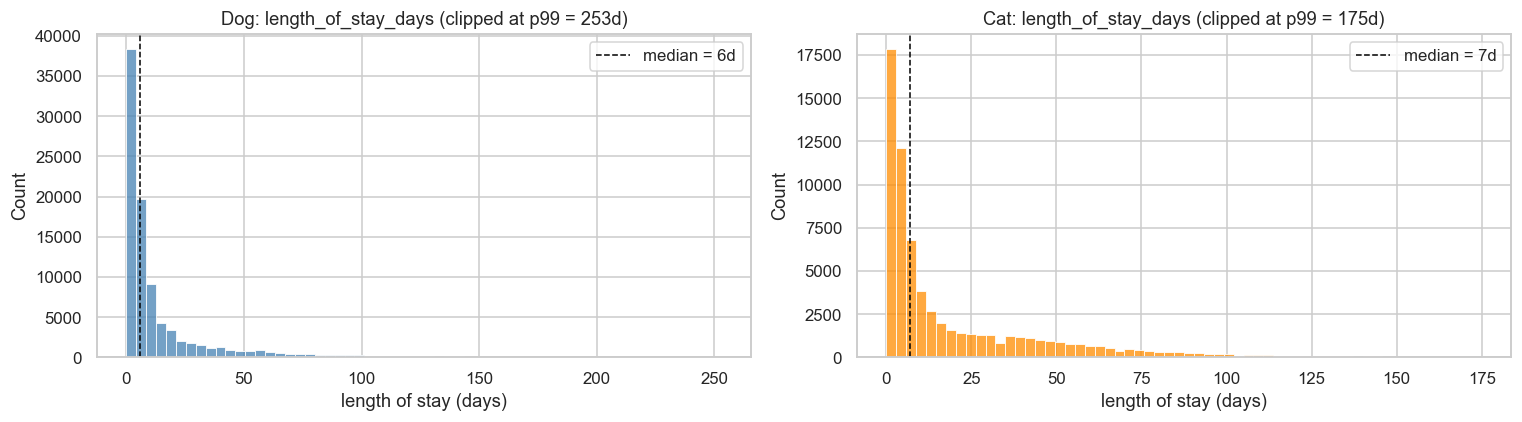

               Dog       Cat
count     93728.00  68737.00
mean         20.81     23.14
std          53.51     42.85
min           0.00      0.00
25%           2.00      2.00
50%           6.00      7.00
75%          15.00     31.00
max        1913.00   1745.00
skewness      8.30      8.37

Dog: median = 6d | p95 = 87d | max = 1913d | skewness = 8.30  ->  STRONG right-skew -> long tail; most animals leave quickly
Cat: median = 7d | p95 = 86d | max = 1745d | skewness = 8.37  ->  STRONG right-skew -> long tail; most animals leave quickly


In [12]:
# length_of_stay_days is a LEAKAGE column (post-outcome) — shown here for EDA only, never a feature.
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
for ax, (sp, frame, color) in zip(axes, [('Dog', dogs, DOG_COLOR), ('Cat', cats, CAT_COLOR)]):
    los = frame['length_of_stay_days']
    cap = los.quantile(0.99)
    sns.histplot(los[los <= cap], bins=60, color=color, ax=ax)
    ax.axvline(los.median(), color='black', ls='--', lw=1, label=f'median = {los.median():.0f}d')
    ax.set_title(f'{sp}: length_of_stay_days (clipped at p99 = {cap:.0f}d)')
    ax.set_xlabel('length of stay (days)'); ax.legend()
fig.tight_layout(); plt.show()

desc = pd.concat({'Dog': dogs['length_of_stay_days'].describe(),
                  'Cat': cats['length_of_stay_days'].describe()}, axis=1)
desc.loc['skewness'] = [dogs['length_of_stay_days'].skew(), cats['length_of_stay_days'].skew()]
print(desc.round(2))
print()
for sp, frame in [('Dog', dogs), ('Cat', cats)]:
    los = frame['length_of_stay_days']
    sk = los.skew()
    flag = 'STRONG right-skew -> long tail; most animals leave quickly' if sk > 1 else 'mild skew'
    print(f'{sp}: median = {los.median():.0f}d | p95 = {los.quantile(.95):.0f}d | '
          f'max = {los.max():.0f}d | skewness = {sk:.2f}  ->  {flag}')

## 3. Bivariate Analysis — features vs `is_long_stay`
_Dogs and cats computed separately. Red dashed line = that species' overall long-stay rate. **Higher bar = higher long-stay risk** — note this reads opposite to an adoption analysis, where a high rate would be good; here a high rate flags animals that linger._

### 3.0 Reusable helper

In [13]:
def plot_long_stay_rate_by(col, data, top_n=None, min_count=30,
                           ax=None, title=None, color='steelblue', sort='rate'):
    """Horizontal bar chart of long-stay rate per category of `col` within `data`.

    - Drops categories with fewer than `min_count` rows.
    - If `top_n` is given, keeps the `top_n` most frequent categories.
    - Draws a red dashed line at this data's overall is_long_stay mean (the species' overall long-stay rate).
    - Annotates each bar with its sample size (n=...).
    - sort='rate' orders bars by long-stay rate, so the MOST long-stay-prone categories sit at the
      top — read top = highest long-stay RISK (the opposite direction to an adoption chart).
      sort='index' keeps category order (use for ordered buckets like age_bucket).
    """
    g = data.groupby(col, observed=True)[TARGET].agg(rate='mean', n='count')
    g = g[g['n'] >= min_count]
    if top_n is not None:
        g = g.nlargest(top_n, 'n')
    g = g.sort_values('rate') if sort == 'rate' else g.sort_index()
    if ax is None:
        _, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(g))))
    labels = [str(LABEL_MAP.get(col, {}).get(i, i)) for i in g.index]
    ax.barh(labels, g['rate'].values, color=color)
    overall = data[TARGET].mean()
    ax.axvline(overall, color='red', ls='--', lw=1.5, label=f'overall {overall:.2f}')
    for y, (rate, n) in enumerate(zip(g['rate'], g['n'])):
        ax.text(min(rate + 0.01, 0.99), y, f'n={int(n)}', va='center', fontsize=8)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel('long-stay rate')
    ax.set_title(title or f'long-stay rate by {col}')
    ax.legend(loc='lower right', fontsize=8)
    return ax

### 3.1 Long-stay rate by each categorical feature (Dog | Cat)

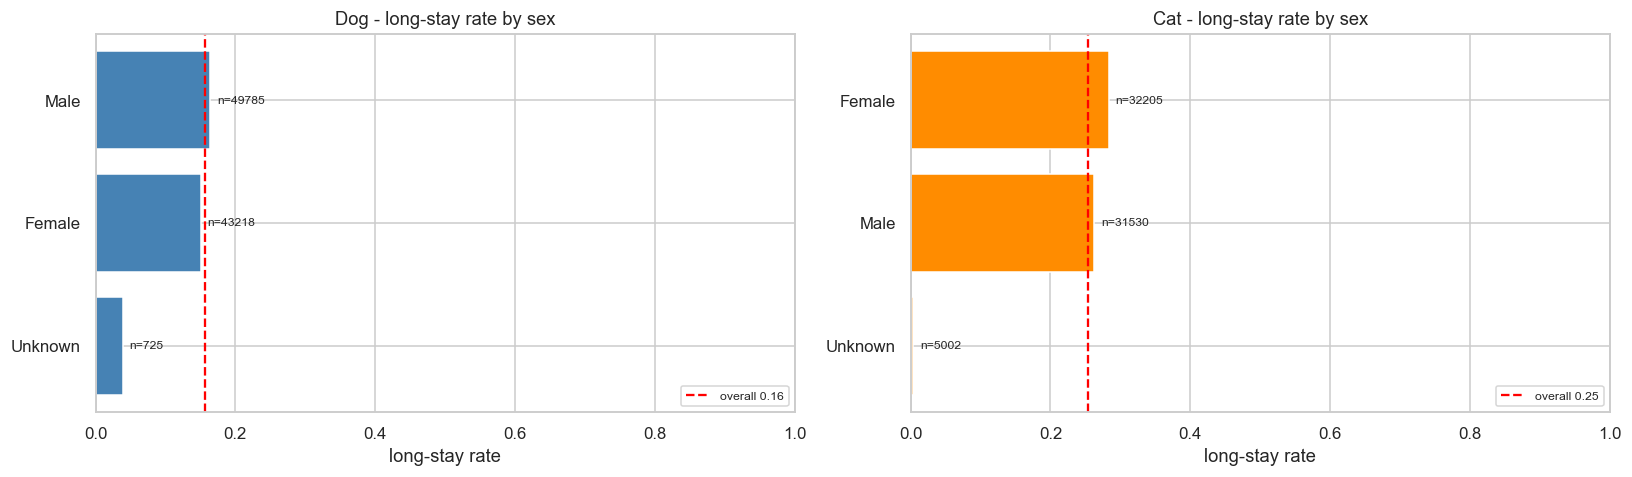

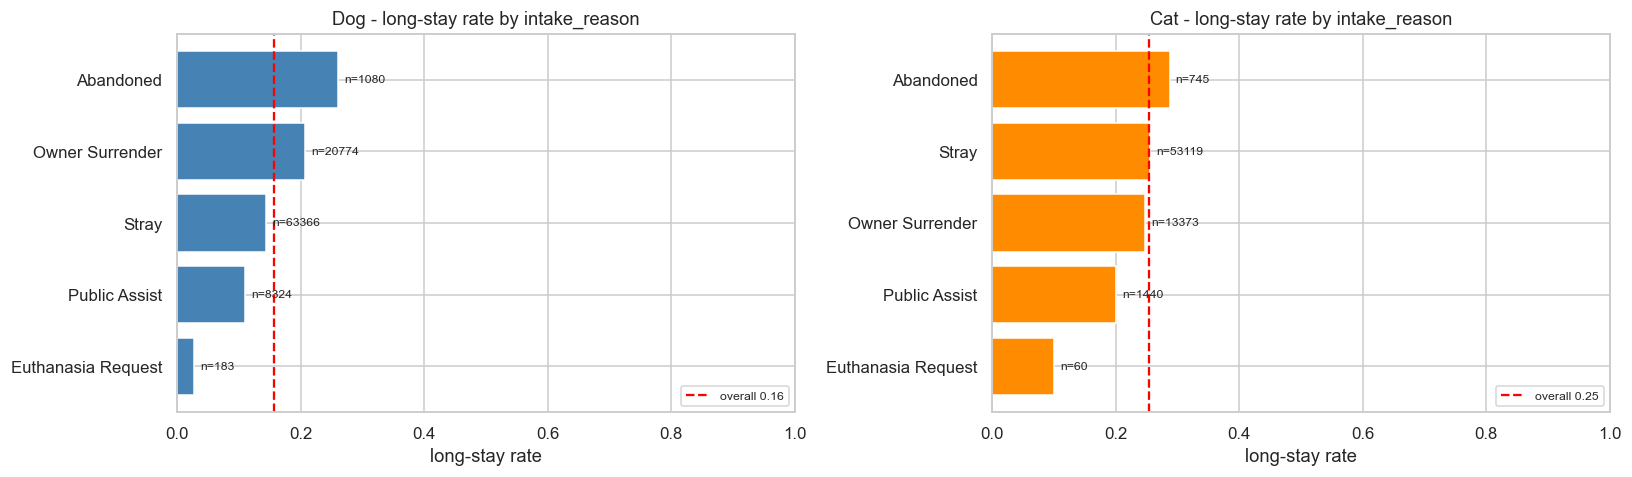

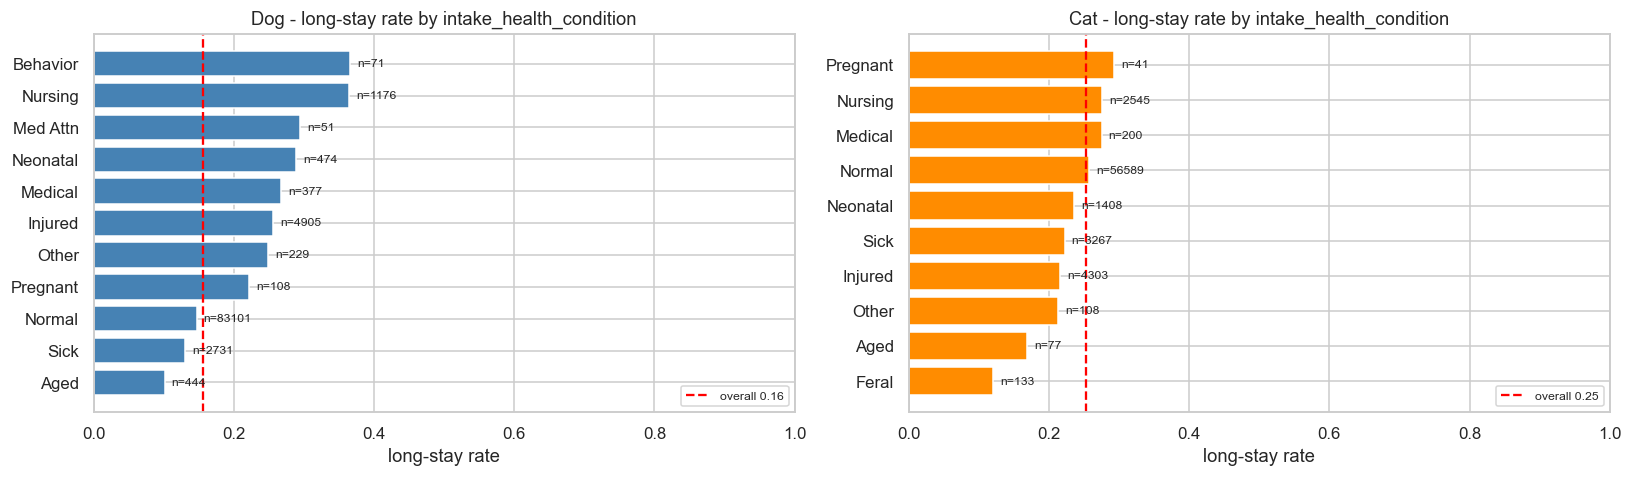

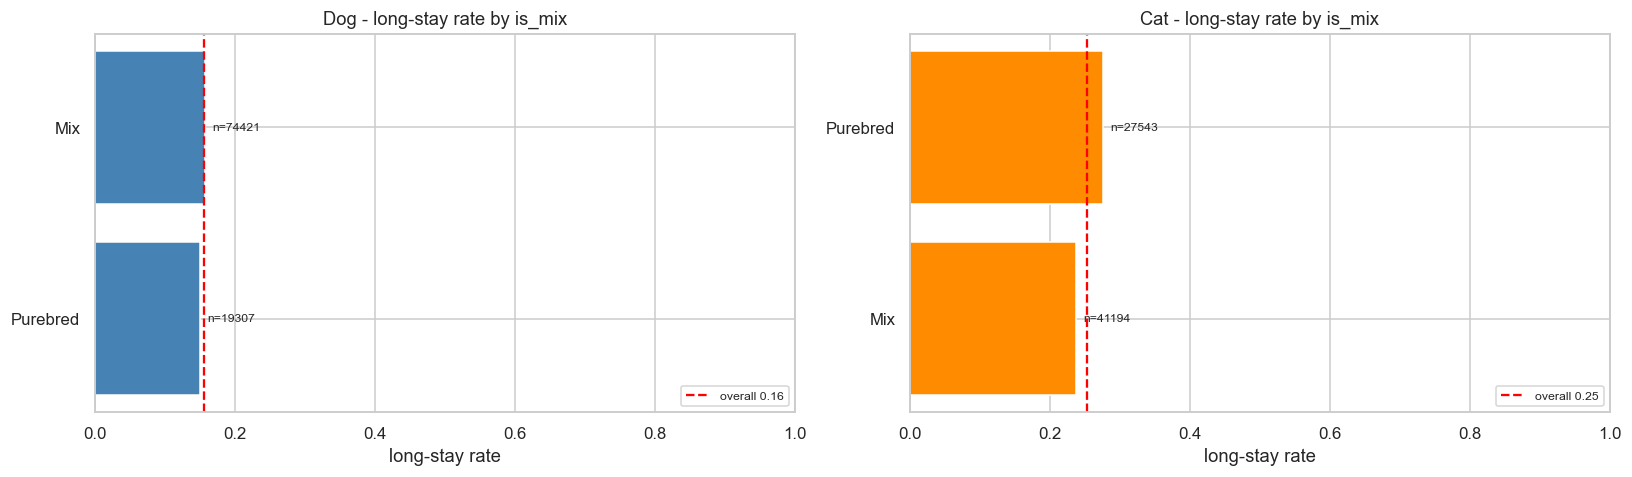

In [14]:
for col in ['sex', 'intake_reason', 'intake_health_condition', 'is_mix']:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    plot_long_stay_rate_by(col, dogs, ax=axes[0], min_count=30,
                          title=f'Dog - long-stay rate by {col}', color=DOG_COLOR)
    plot_long_stay_rate_by(col, cats, ax=axes[1], min_count=30,
                          title=f'Cat - long-stay rate by {col}', color=CAT_COLOR)
    fig.tight_layout(); plt.show()

### 3.2 Long-stay rate by breed (top 15 by volume, min 100 rows)

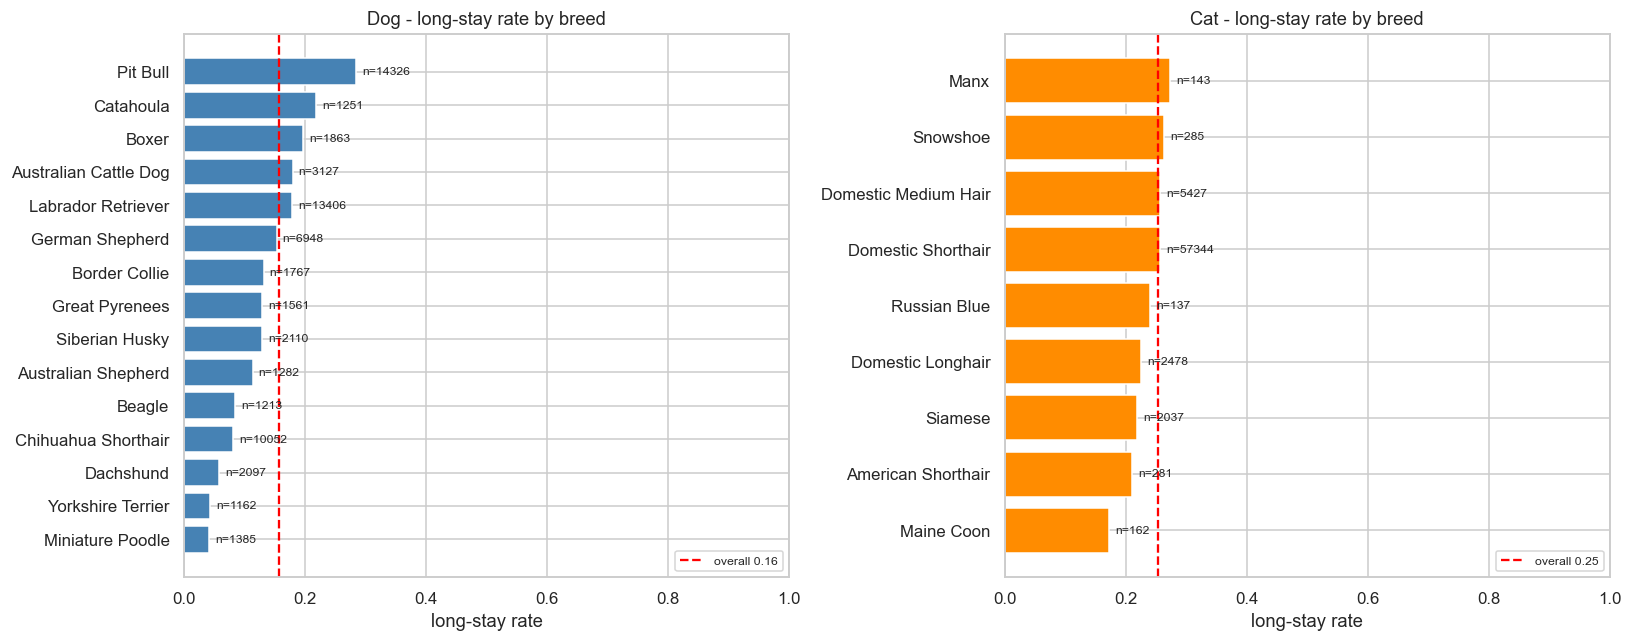

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_long_stay_rate_by('primary_breed', dogs, top_n=15, min_count=100, ax=axes[0],
                      title='Dog - long-stay rate by breed', color=DOG_COLOR)
plot_long_stay_rate_by('primary_breed', cats, top_n=15, min_count=100, ax=axes[1],
                      title='Cat - long-stay rate by breed', color=CAT_COLOR)
fig.tight_layout(); plt.show()

### 3.3 Long-stay rate by age bucket (Dog | Cat)

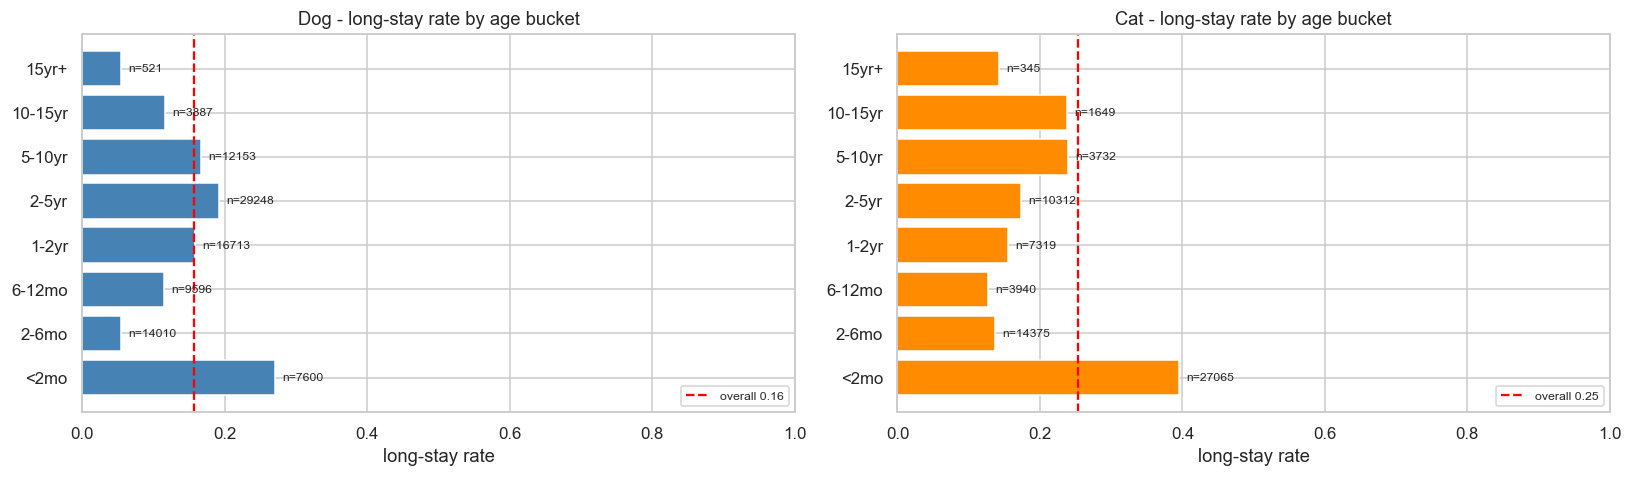

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_long_stay_rate_by('age_bucket', dogs, ax=axes[0], min_count=30, sort='index',
                      title='Dog - long-stay rate by age bucket', color=DOG_COLOR)
plot_long_stay_rate_by('age_bucket', cats, ax=axes[1], min_count=30, sort='index',
                      title='Cat - long-stay rate by age bucket', color=CAT_COLOR)
fig.tight_layout(); plt.show()

### 3.4 Long-stay rate by color (Dog | Cat)
Shown for both `primary_color` (base color) and `pattern` (Solid / Tabby / Brindle / …).

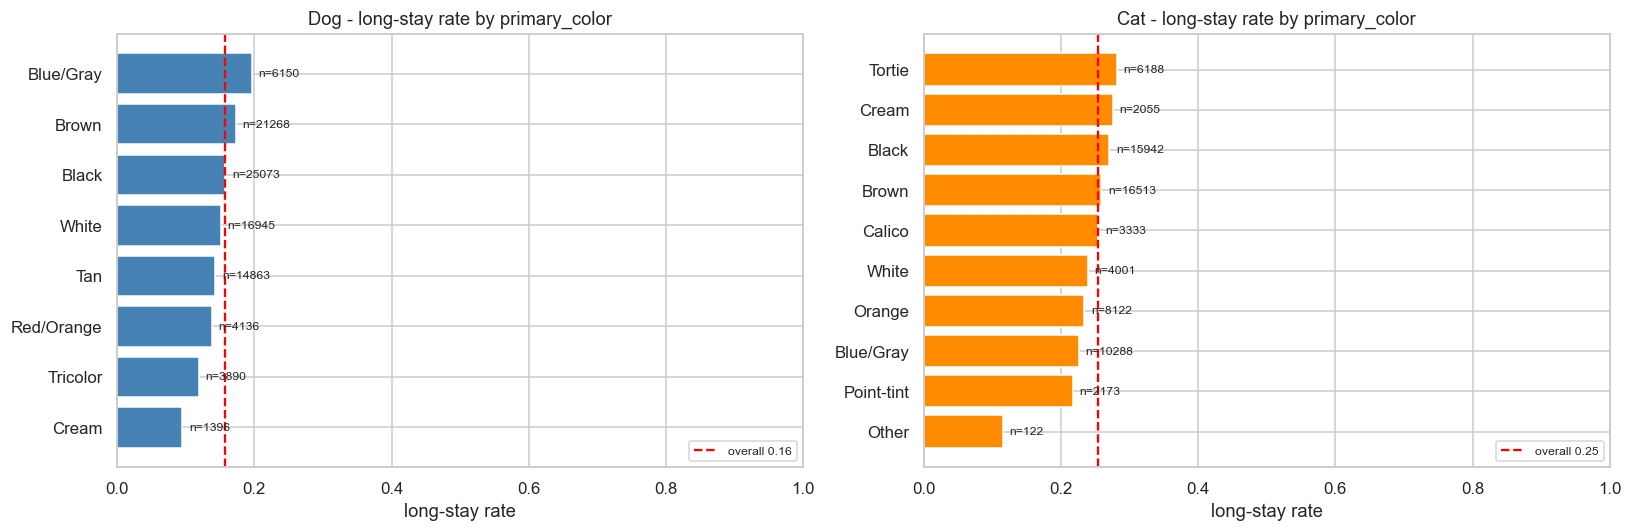

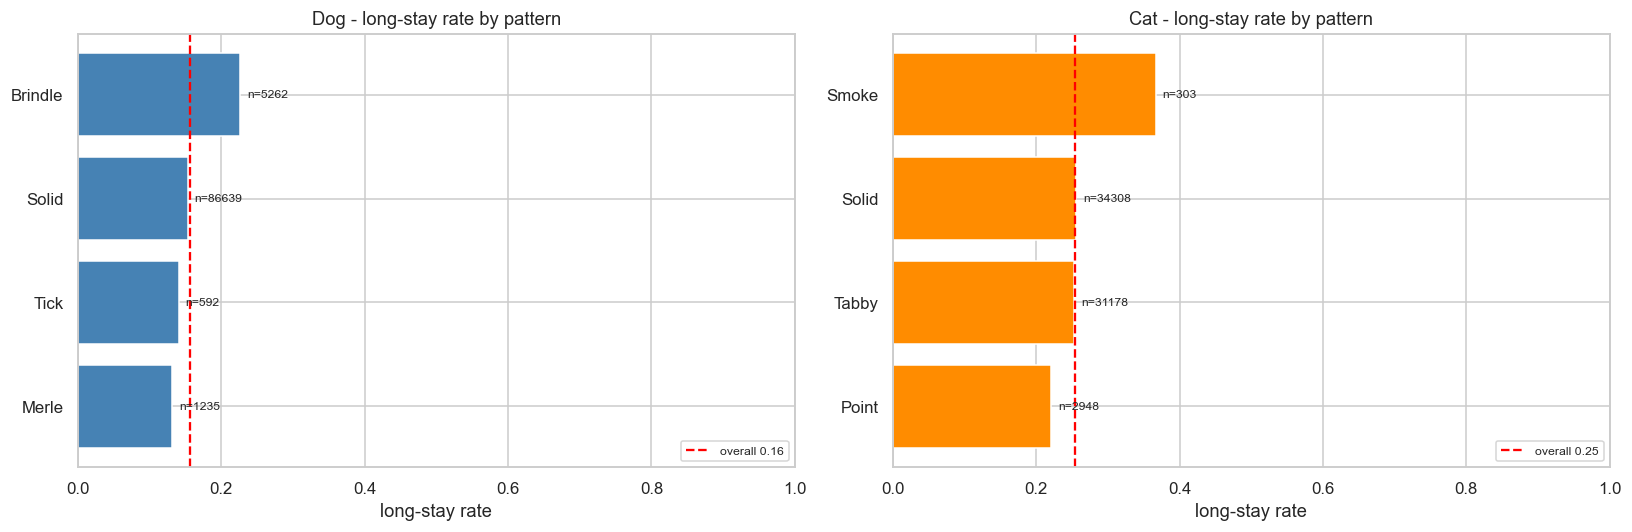

In [17]:
for col in ['primary_color', 'pattern']:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    plot_long_stay_rate_by(col, dogs, ax=axes[0], min_count=30,
                          title=f'Dog - long-stay rate by {col}', color=DOG_COLOR)
    plot_long_stay_rate_by(col, cats, ax=axes[1], min_count=30,
                          title=f'Cat - long-stay rate by {col}', color=CAT_COLOR)
    fig.tight_layout(); plt.show()

## 4. Multivariate

### 4.1 Headline: dog vs cat long-stay rate by age bucket (one chart)
This is the key reason the two species must not be pooled.

**Reading the chart/table below (described from the actual output, not assumed):** for both species the youngest intakes (under ~2 months) show the highest long-stay rate, then the 2–6 month bucket drops to among the lowest. From there the two species diverge — **dogs** peak again in prime adulthood (the mid age buckets) and fall back for the oldest animals, while **cats** trend upward with age, with senior cats staying elevated. The age→long-stay relationship is non-monotonic and species-specific (not a clean mirror of any adoption curve), which is exactly why dogs and cats are modeled separately.

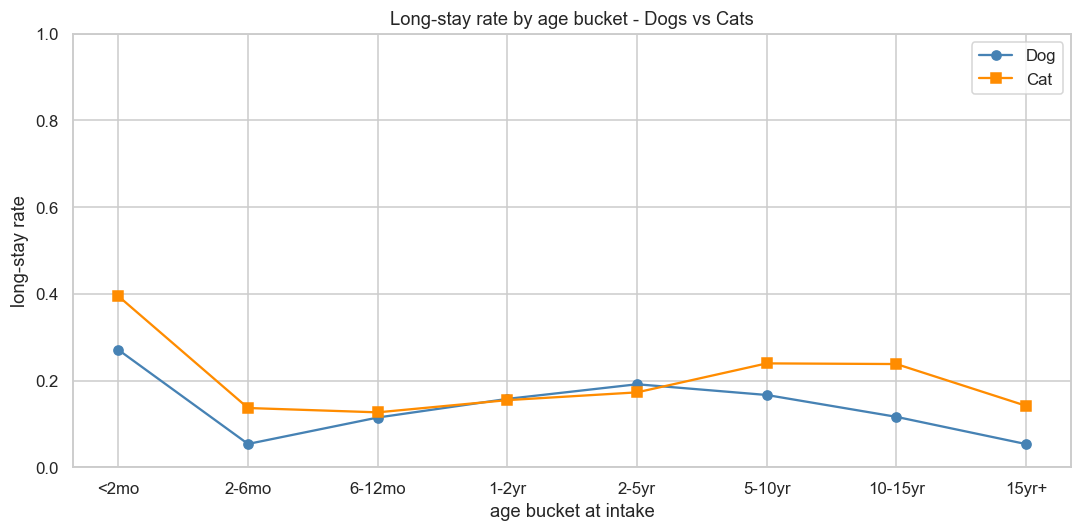

              Dog    Cat
age_bucket              
<2mo        0.271  0.395
2-6mo       0.054  0.137
6-12mo      0.115  0.127
1-2yr       0.158  0.155
2-5yr       0.192  0.173
5-10yr      0.167  0.240
10-15yr     0.117  0.238
15yr+       0.054  0.142


In [18]:
dog_rate = dogs.groupby('age_bucket', observed=True)[TARGET].mean().reindex(AGE_LABELS)
cat_rate = cats.groupby('age_bucket', observed=True)[TARGET].mean().reindex(AGE_LABELS)

plt.figure(figsize=(10, 5))
plt.plot(AGE_LABELS, dog_rate.values, marker='o', color=DOG_COLOR, label='Dog')
plt.plot(AGE_LABELS, cat_rate.values, marker='s', color=CAT_COLOR, label='Cat')
plt.ylabel('long-stay rate'); plt.xlabel('age bucket at intake')
plt.title('Long-stay rate by age bucket - Dogs vs Cats')
plt.ylim(0, 1); plt.legend(); plt.tight_layout(); plt.show()

print(pd.DataFrame({'Dog': dog_rate, 'Cat': cat_rate}).round(3))

### 4.2 Correlation heatmaps — computed separately per species
**Spearman** rank correlation on an encoded numeric view: `is_mix`, `is_sn` (previously spayed/neutered), `health_normal` (intake condition == Normal), `age_days`, and the target.

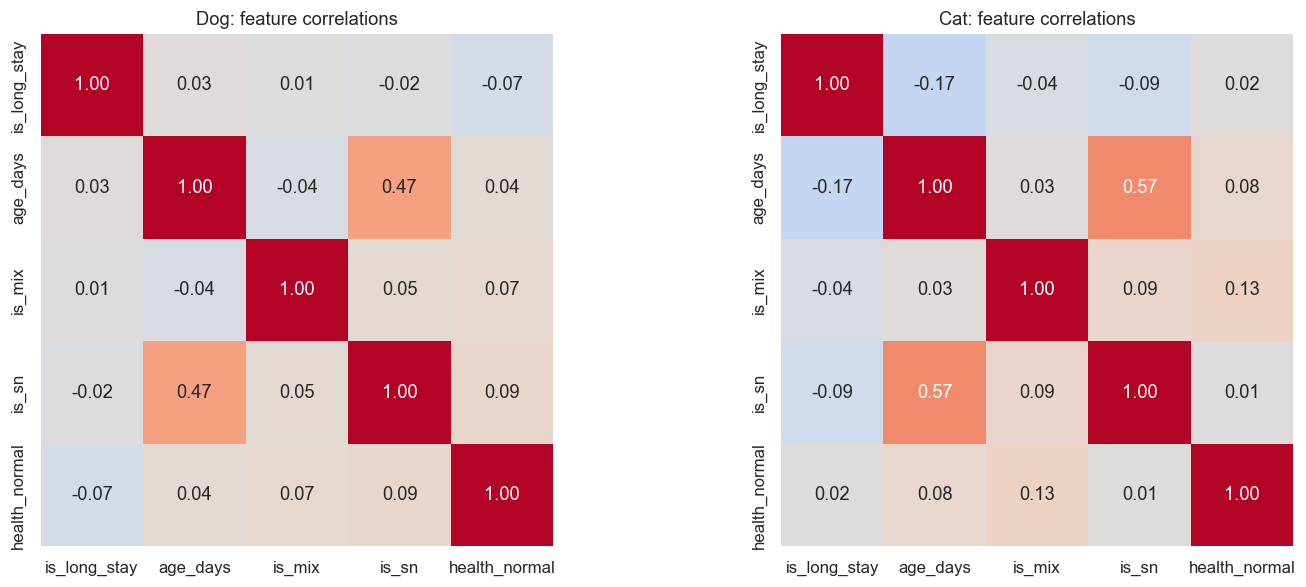

In [19]:
def encode_for_corr(frame):
    return pd.DataFrame({
        'is_long_stay':  frame[TARGET],
        'age_days':      frame['age_at_intake_days'],
        'is_mix':        frame['is_mix'],
        'is_sn':      frame['is_previously_spayed_neutered'],
        'health_normal': (frame['intake_health_condition'] == 'Normal').astype(int),
    })

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (sp, frame) in zip(axes, [('Dog', dogs), ('Cat', cats)]):
    corr = encode_for_corr(frame).corr(method='spearman')
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, square=True, cbar=False, ax=ax)
    ax.set_title(f'{sp}: feature correlations')
fig.tight_layout(); plt.show()

### 4.3 Mutual information — categorical features
Pearson can't handle string columns, so `mutual_info_classif` fills the gap. Each categorical feature is ordinal-encoded to integers (all treated as `discrete_features=True`), then MI vs `is_long_stay` is computed per species. Higher score = more information about the long-stay target.

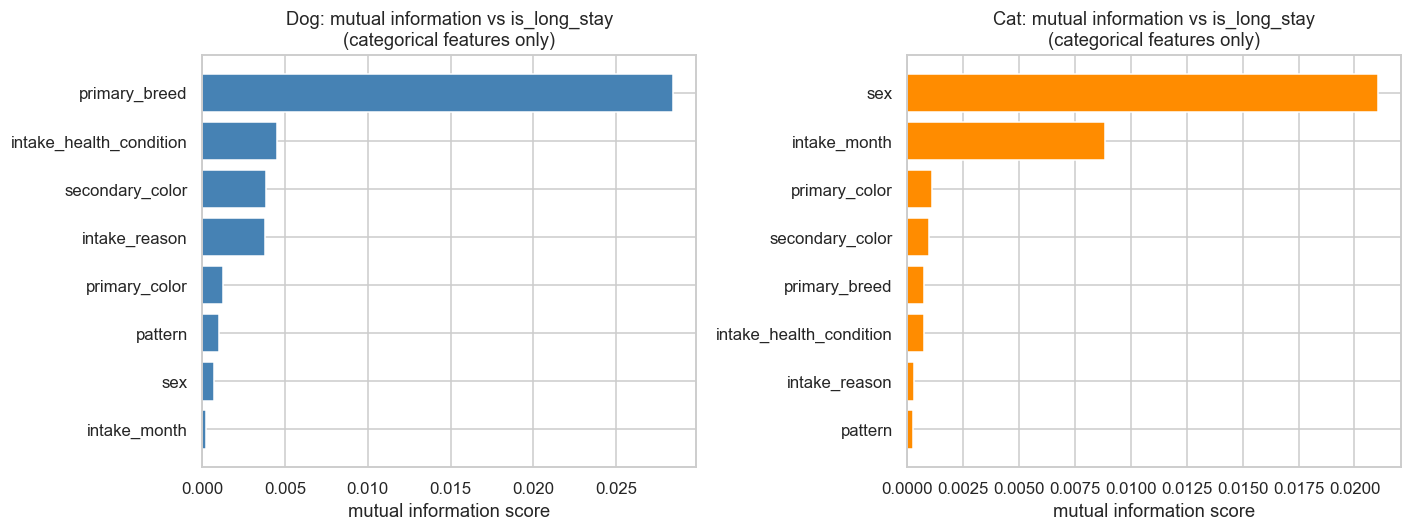

In [20]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

CAT_COLS = ['sex', 'intake_reason', 'intake_health_condition',
            'primary_color', 'pattern', 'primary_breed', 'intake_month','secondary_color']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (sp, frame, color) in zip(axes, [('Dog', dogs, DOG_COLOR), ('Cat', cats, CAT_COLOR)]):
    sub = frame[CAT_COLS + [TARGET]].copy()
    for c in CAT_COLS:
        sub[c] = sub[c].fillna('Unknown')

    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X = enc.fit_transform(sub[CAT_COLS])
    y = sub[TARGET].values

    mi = mutual_info_classif(X, y, discrete_features=True, random_state=42)
    scores = pd.Series(mi, index=CAT_COLS).sort_values()

    ax.barh(scores.index, scores.values, color=color)
    ax.set_title(f'{sp}: mutual information vs is_long_stay\n(categorical features only)')
    ax.set_xlabel('mutual information score')

fig.tight_layout(); plt.show()

### 4.4 Color × sex association (Dog | Cat)
Both are categorical, so the "correlation matrix" is built by one-hot encoding `primary_color` and `sex`, then taking the Pearson correlation between each color dummy and each sex dummy (for two 0/1 variables this is the **phi** coefficient). Watch the cats: tortie & calico coats are almost always **female** (the coat-color gene is X-linked).

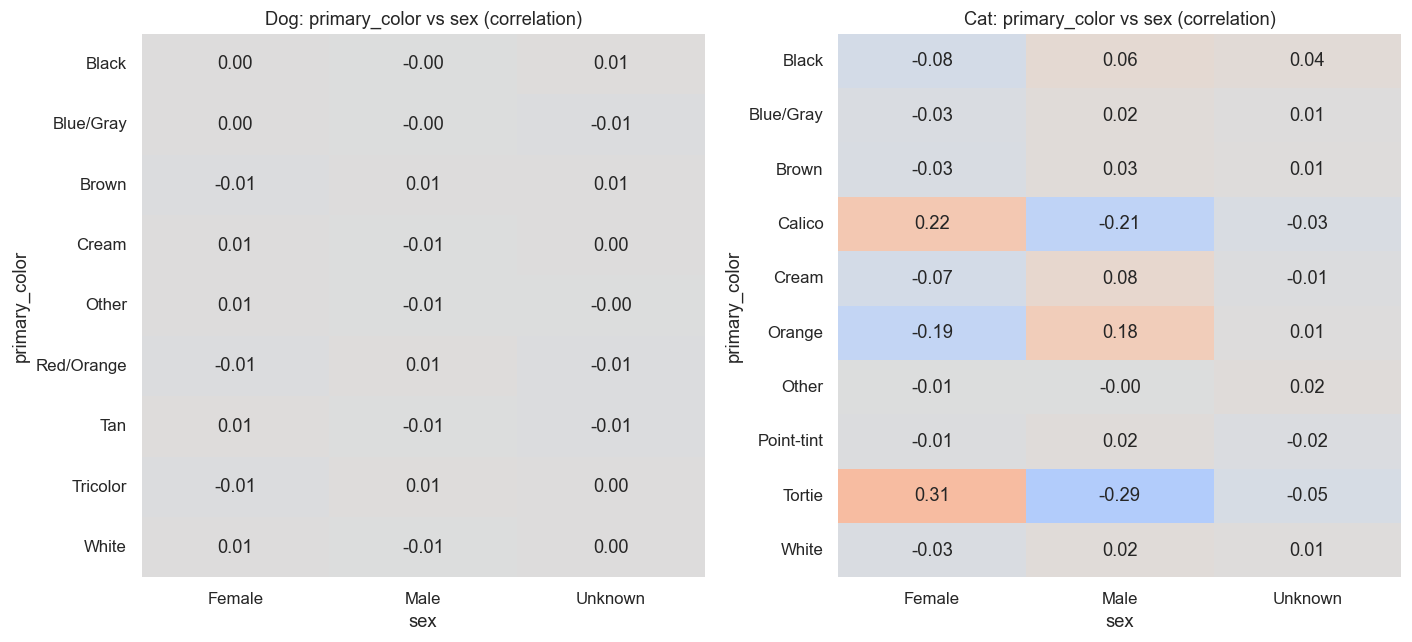

In [21]:
def color_sex_corr(frame, color_col='primary_color'):
    """Correlation of each color indicator (rows) with each sex indicator (cols)."""
    cd = pd.get_dummies(frame[color_col]).astype(int)
    sd = pd.get_dummies(frame['sex']).astype(int)
    return pd.DataFrame(
        {s: cd.apply(lambda col: np.corrcoef(col, sd[s])[0, 1]) for s in sd.columns}
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (sp, frame) in zip(axes, [('Dog', dogs), ('Cat', cats)]):
    M = color_sex_corr(frame)
    sns.heatmap(M, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, cbar=False, ax=ax)
    ax.set_title(f'{sp}: primary_color vs sex (correlation)')
    ax.set_xlabel('sex'); ax.set_ylabel('primary_color')
fig.tight_layout(); plt.show()

## 5. Temporal Analysis
_Uses the full `df` (all dog/cat outcomes), not the per-species frames._

**2013 and 2025 are partial years** — exclude them when reading year-over-year trends.

### 5.1 Intake volume per year

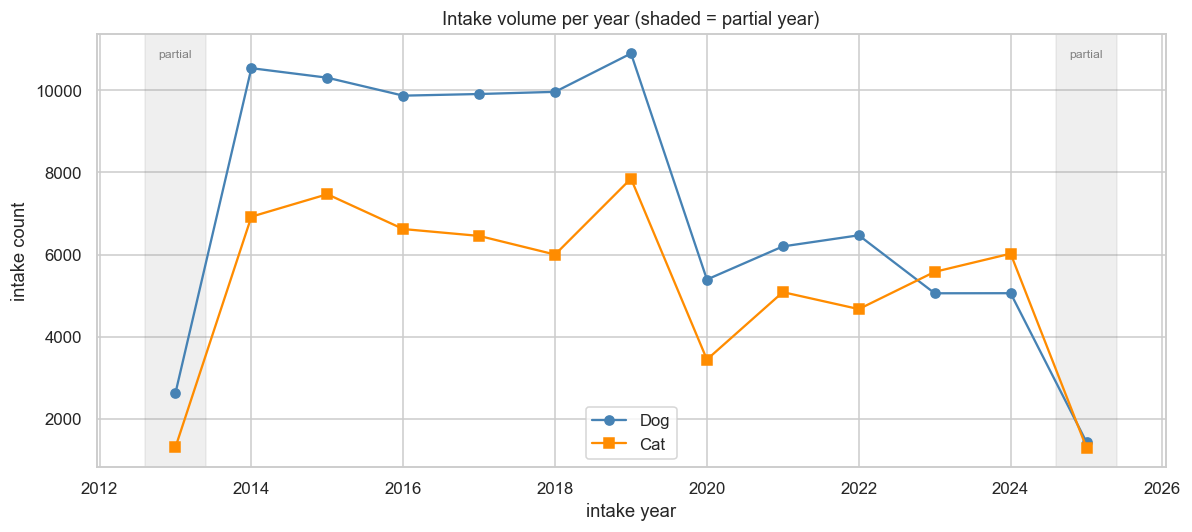

In [22]:
yearly = df.groupby(['intake_year', 'animal_type']).size().unstack()
plt.figure(figsize=(11, 5))
plt.plot(yearly.index, yearly['Dog'], marker='o', color=DOG_COLOR, label='Dog')
plt.plot(yearly.index, yearly['Cat'], marker='s', color=CAT_COLOR, label='Cat')
for yr in (2013, 2025):
    plt.axvspan(yr - 0.4, yr + 0.4, color='grey', alpha=0.12)
plt.text(2013, plt.ylim()[1]*0.95, 'partial', ha='center', fontsize=8, color='grey')
plt.text(2025, plt.ylim()[1]*0.95, 'partial', ha='center', fontsize=8, color='grey')
plt.ylabel('intake count'); plt.xlabel('intake year')
plt.title('Intake volume per year (shaded = partial year)')
plt.legend(); plt.tight_layout(); plt.show()

### 5.2 Seasonality: intake volume per month (kitten-season check)
Expect **cats to spike May-Sep**.

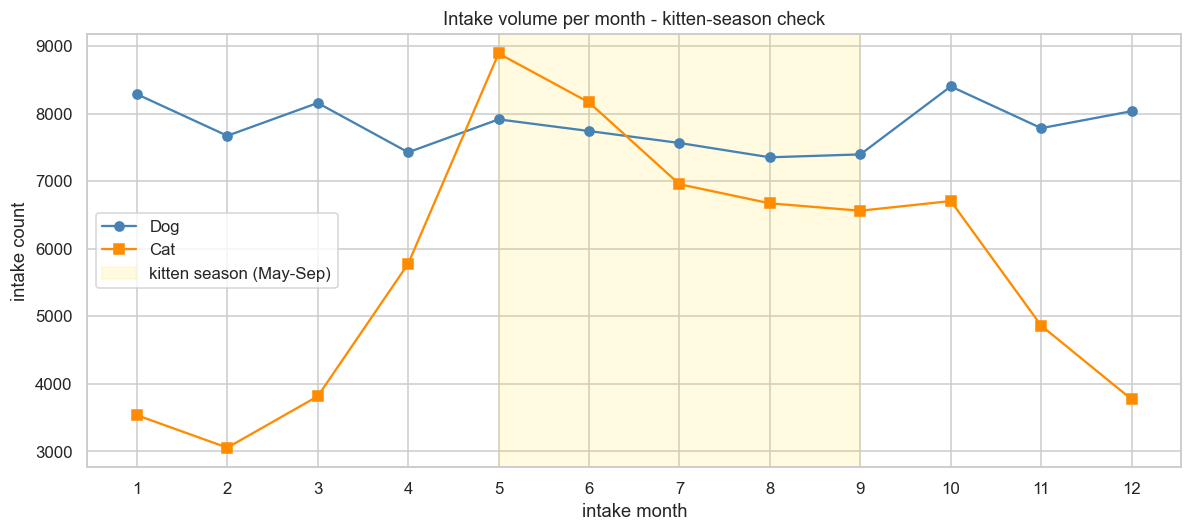

In [23]:
monthly = df.groupby(['intake_month', 'animal_type']).size().unstack()
plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly['Dog'], marker='o', color=DOG_COLOR, label='Dog')
plt.plot(monthly.index, monthly['Cat'], marker='s', color=CAT_COLOR, label='Cat')
plt.axvspan(5, 9, color='gold', alpha=0.12, label='kitten season (May-Sep)')
plt.xticks(range(1, 13))
plt.ylabel('intake count'); plt.xlabel('intake month')
plt.title('Intake volume per month - kitten-season check')
plt.legend(); plt.tight_layout(); plt.show()

### 5.3 Long-stay rate per year (data-drift check)

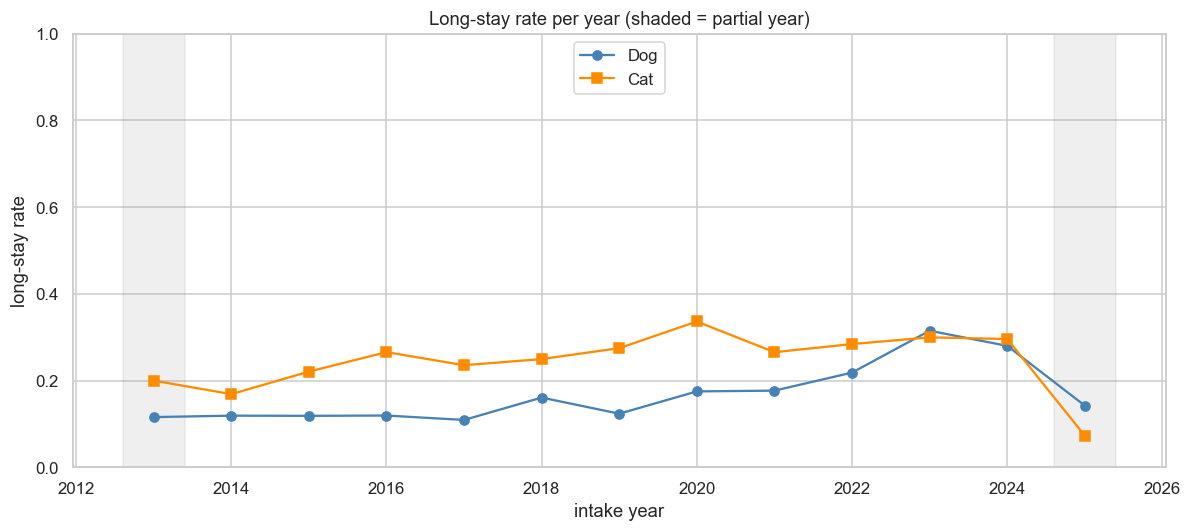

animal_type    Cat    Dog
intake_year              
2013         0.200  0.116
2014         0.169  0.119
2015         0.221  0.119
2016         0.266  0.120
2017         0.236  0.109
2018         0.250  0.161
2019         0.275  0.124
2020         0.336  0.175
2021         0.266  0.177
2022         0.284  0.219
2023         0.300  0.315
2024         0.296  0.280
2025         0.073  0.142


In [24]:
yr_rate = df.groupby(['intake_year', 'animal_type'])[TARGET].mean().unstack()
plt.figure(figsize=(11, 5))
plt.plot(yr_rate.index, yr_rate['Dog'], marker='o', color=DOG_COLOR, label='Dog')
plt.plot(yr_rate.index, yr_rate['Cat'], marker='s', color=CAT_COLOR, label='Cat')
for yr in (2013, 2025):
    plt.axvspan(yr - 0.4, yr + 0.4, color='grey', alpha=0.12)
plt.ylabel('long-stay rate'); plt.xlabel('intake year'); plt.ylim(0, 1)
plt.title('Long-stay rate per year (shaded = partial year)')
plt.legend(); plt.tight_layout(); plt.show()

print(yr_rate.round(3))